#########    All "our" in the following code refers to Joint Cabernet.

In [19]:
import pandas as pd
import numpy as np
import anndata as ad
import subprocess
import os
from tqdm.notebook import tqdm

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
with open("../../../../input/01-youth/subclass_order_for_integration_with_zeng.txt", "rt") as f:
    subclass_list=f.read().split("\n")[:-1]
subclass_list=[i for i in subclass_list if "NN" not in i]

csv_path = "../../../../input/01-youth/subclass_our_liu.csv"
df = pd.read_csv(csv_path, sep=',')
df = df.iloc[:len(subclass_list),:]

In [ ]:
df_states=ad.read_h5ad(f'{indir}/5hmCG_DMR_states_neuron_1vsOthers.h5ad').to_df()

In [22]:
temp=df_states.loc[:,(np.nansum(df_states==1, axis=0)>0)]

In [23]:
temp.columns

Index(['chr1_3019020_3019545', 'chr1_3023074_3023890', 'chr1_3032861_3034192',
       'chr1_3044312_3044993', 'chr1_3074366_3074990', 'chr1_3076706_3077471',
       'chr1_3084207_3084772', 'chr1_3090853_3092180', 'chr1_3096288_3097965',
       'chr1_3098659_3098992',
       ...
       'chr19_61238016_61238441', 'chr19_61267872_61268178',
       'chr19_61268856_61269200', 'chr19_61286843_61287489',
       'chr19_61288301_61288928', 'chr19_61299973_61300405',
       'chr19_61313965_61314559', 'chr19_61317667_61318070',
       'chr19_61319797_61320171', 'chr19_61329595_61329910'],
      dtype='object', name='segment', length=184573)

<Axes: >

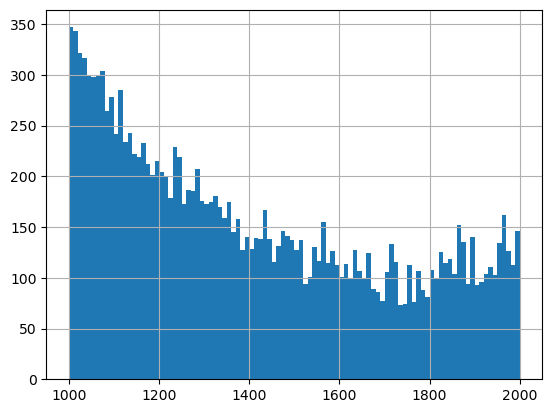

In [24]:
pd.Series(temp.columns).apply(lambda x : int(x.split('_')[2])-int(x.split('_')[1])).hist(range=(1000,2000), bins=100)

In [25]:
temp=df_states.loc[:,(np.nansum(df_states==1, axis=0)==1)]

In [26]:
temp.columns

Index(['chr1_3023074_3023890', 'chr1_3032861_3034192', 'chr1_3044312_3044993',
       'chr1_3074366_3074990', 'chr1_3084207_3084772', 'chr1_3090853_3092180',
       'chr1_3096288_3097965', 'chr1_3098659_3098992', 'chr1_3104390_3104863',
       'chr1_3105547_3105987',
       ...
       'chr19_61193790_61194246', 'chr19_61203588_61203873',
       'chr19_61204677_61205162', 'chr19_61238016_61238441',
       'chr19_61267872_61268178', 'chr19_61268856_61269200',
       'chr19_61286843_61287489', 'chr19_61299973_61300405',
       'chr19_61313965_61314559', 'chr19_61317667_61318070'],
      dtype='object', name='segment', length=122947)

<Axes: >

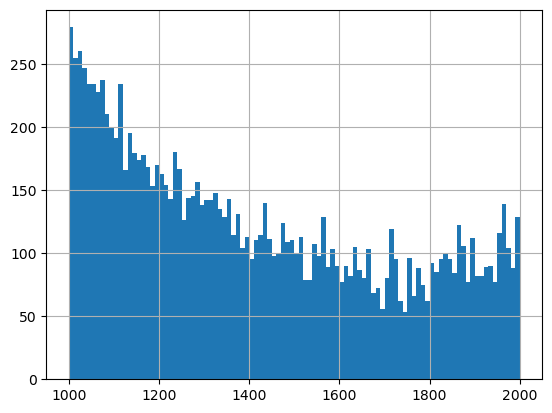

In [27]:
pd.Series(temp.columns).apply(lambda x : int(x.split('_')[2])-int(x.split('_')[1])).hist(range=(1000,2000), bins=100)

In [ ]:
for subclass_ in subclass_list:
    states_ = df_states.loc[subclass_]
    states_hyper = states_[states_==+1]
    with open(f'{outdir}/hyper_DHMR_bedgraph/{df[df['subclass_our']==subclass_]['subclass_liu'].values[0]}.hyper_DHMR.bedgraph', 'wt') as f:
        for segment_ in states_hyper.index:
            f.write(segment_.replace('_', '\t') + '\t1\n')

In [7]:
df[df['subclass_our']==subclass_]['subclass_liu'].values[0]

'ACB-BST-FS_D1_Gaba'

In [ ]:
for i in tqdm(os.listdir(f'{outdir}/hyper_DHMR_bedgraph')):
    print(i)
    subprocess.run(f'cat {outdir}/hyper_DHMR_bedgraph/{i} | sort -k1,1 -k2,2n  > {outdir}/hyper_DHMR_sorted_bedgraph/{i.replace(".bedgraph", '_sorted.bedgraph')}', shell=True)

  0%|          | 0/25 [00:00<?, ?it/s]

L4_5_IT_CTX_Glut.hyper_DHMR.bedgraph
CLA-EPd-CTX_Car3_Glut.hyper_DHMR.bedgraph
L2_3_IT_RSP_Glut.hyper_DHMR.bedgraph
L2_3_IT_CTX_Glut.hyper_DHMR.bedgraph
ACB-BST-FS_D1_Gaba.hyper_DHMR.bedgraph
OB-out_Frmd7_Gaba.hyper_DHMR.bedgraph
L4_RSP-ACA_Glut.hyper_DHMR.bedgraph
L5_NP_CTX_Glut.hyper_DHMR.bedgraph
OB-STR-CTX_Inh_IMN.hyper_DHMR.bedgraph
L6_CT_CTX_Glut.hyper_DHMR.bedgraph
STR_D1_Gaba.hyper_DHMR.bedgraph
Lamp5_Gaba.hyper_DHMR.bedgraph
SUB-ProS_Glut.hyper_DHMR.bedgraph
CA3_Glut.hyper_DHMR.bedgraph
OB-in_Frmd7_Gaba.hyper_DHMR.bedgraph
CA1-ProS_Glut.hyper_DHMR.bedgraph
L5_IT_CTX_Glut.hyper_DHMR.bedgraph
Pvalb_Gaba.hyper_DHMR.bedgraph
STR_D2_Gaba.hyper_DHMR.bedgraph
OB_Eomes_Ms4a15_Glut.hyper_DHMR.bedgraph
DG_Glut.hyper_DHMR.bedgraph
OB_Dopa-Gaba.hyper_DHMR.bedgraph
Sncg_Gaba.hyper_DHMR.bedgraph
Sst_Gaba.hyper_DHMR.bedgraph
L5_ET_CTX_Glut.hyper_DHMR.bedgraph


In [45]:
a=1
f'{"{"}'

'{'

In [ ]:
for i in tqdm(os.listdir(f'{outdir}/hyper_DHMR_sorted_bedgraph/')):
    print(i)
    subprocess.run(f"""
    bedGraphToBigWig=${indir}/UCSC_tools/bedGraphToBigWig
    chrom_size=../../../../input/reference_genome/mm10.chrom.sizes.txt
    
    $bedGraphToBigWig {outdir}/hyper_DHMR_sorted_bedgraph/{i} $chrom_size {outdir}/hyper_DHMR_sorted_bigwig/{i.replace('_sorted.bedgraph', '.bw')}
    """, shell=True)

  0%|          | 0/25 [00:00<?, ?it/s]

OB-STR-CTX_Inh_IMN.hyper_DHMR_sorted.bedgraph
Lamp5_Gaba.hyper_DHMR_sorted.bedgraph
L5_ET_CTX_Glut.hyper_DHMR_sorted.bedgraph
L5_NP_CTX_Glut.hyper_DHMR_sorted.bedgraph
L2_3_IT_CTX_Glut.hyper_DHMR_sorted.bedgraph
L4_RSP-ACA_Glut.hyper_DHMR_sorted.bedgraph
DG_Glut.hyper_DHMR_sorted.bedgraph
Sst_Gaba.hyper_DHMR_sorted.bedgraph
CLA-EPd-CTX_Car3_Glut.hyper_DHMR_sorted.bedgraph
OB_Dopa-Gaba.hyper_DHMR_sorted.bedgraph
L6_CT_CTX_Glut.hyper_DHMR_sorted.bedgraph
L5_IT_CTX_Glut.hyper_DHMR_sorted.bedgraph
Sncg_Gaba.hyper_DHMR_sorted.bedgraph
STR_D2_Gaba.hyper_DHMR_sorted.bedgraph
L2_3_IT_RSP_Glut.hyper_DHMR_sorted.bedgraph
CA3_Glut.hyper_DHMR_sorted.bedgraph
ACB-BST-FS_D1_Gaba.hyper_DHMR_sorted.bedgraph
OB_Eomes_Ms4a15_Glut.hyper_DHMR_sorted.bedgraph
L4_5_IT_CTX_Glut.hyper_DHMR_sorted.bedgraph
OB-in_Frmd7_Gaba.hyper_DHMR_sorted.bedgraph
OB-out_Frmd7_Gaba.hyper_DHMR_sorted.bedgraph
SUB-ProS_Glut.hyper_DHMR_sorted.bedgraph
STR_D1_Gaba.hyper_DHMR_sorted.bedgraph
CA1-ProS_Glut.hyper_DHMR_sorted.bedgra